Now it's your turn! Try building a linear regression model that predicts price using **Bedrooms** instead of SquareFootage.
Steps to follow:
1. Define X (Bedrooms) and y (Price)
2. Visualize the relationship (scatter plot)
3. Split the data
4. Create and train the model
5. Visualize the regression line
6. Make predictions and evaluate with R² score
Question to think about: Does Bedrooms predict price as well as SquareFootage?


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("./simple_housing.csv")

In [47]:
df.head()

,SquareFootage,Bedrooms,Price
0,1200,2,189000
1,1350,2,198000
2,1500,3,232000
3,1425,2,205000
4,1600,3,258000


In [48]:
Features = df[["Bedrooms"]]
Target = df["Price"]

X = Features
y = Target


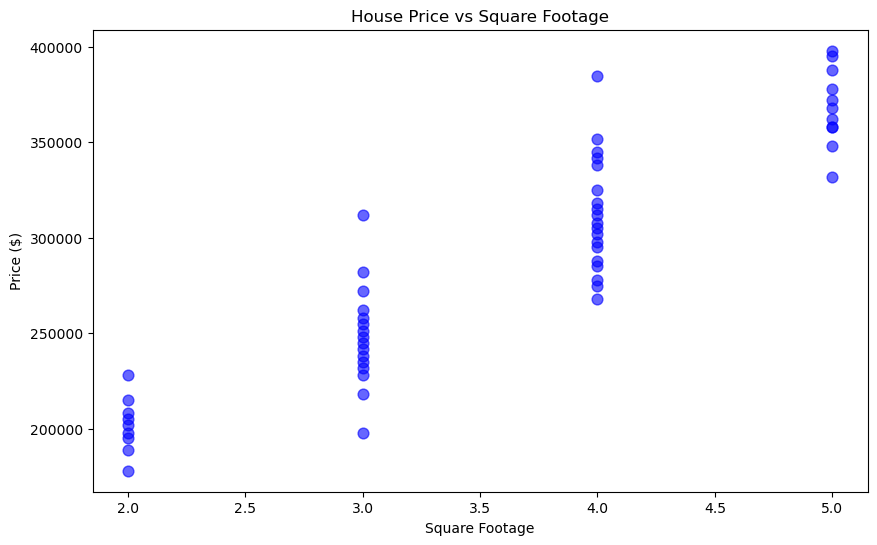

In [49]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.6, s=60)
plt.xlabel('Square Footage')
plt.ylabel('Price ($)')
plt.title('House Price vs Square Footage')
plt.show()

In [50]:
# Split data into testing and training

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [51]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
# 7: Make a prediction

model_prediction = model.predict([[3]])
print(f"${round(model_prediction[0], 2)}\n")

$254122.09



/Users/davidfekke/Documents/python/projects/mynotebooks/lesson-16/.pixi/envs/default/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [53]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
r2

0.769132229992333

/Users/davidfekke/Documents/python/projects/mynotebooks/lesson-16/.pixi/envs/default/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


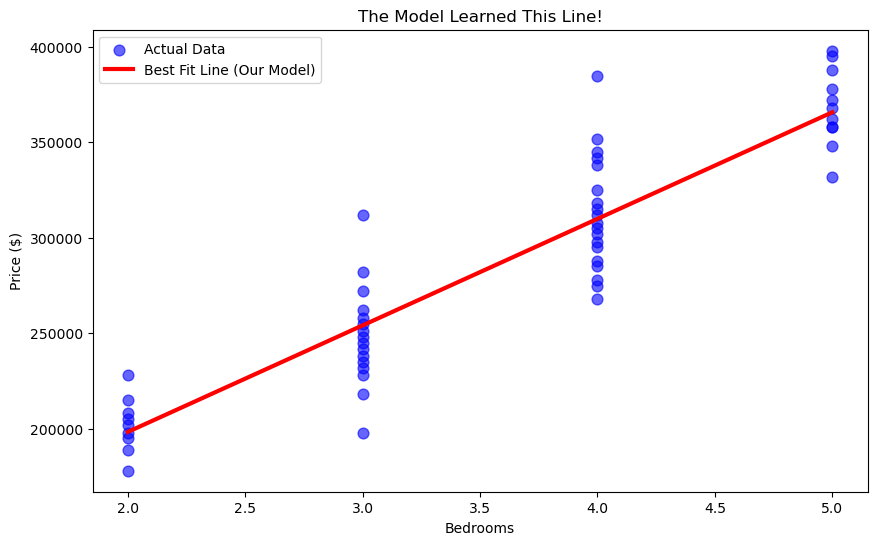

In [54]:
plt.figure(figsize=(10, 6))

# Scatter plot of all data points
plt.scatter(df['Bedrooms'], df['Price'], color='blue', alpha=0.6, s=60, label='Actual Data')

# Create the regression line
X_line = np.linspace(df['Bedrooms'].min(), df['Bedrooms'].max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)

# Plot the line
plt.plot(X_line, y_line, color='red', linewidth=3, label='Best Fit Line (Our Model)')

plt.xlabel('Bedrooms')
plt.ylabel('Price ($)')
plt.title('The Model Learned This Line!')
plt.legend()
plt.show()

In [55]:
# Make predictions on the test set
predictions = model.predict(X_test)

# Compare predictions to actual values
print(f"Actual Prices: {y_test.values}")
print(f"Predicted Prices: {predictions}")

# Evaluate error (Mean Squared Error)
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error: {mse}")


Actual Prices: [255000 251000 275000 338000 358000 398000 262000 312000 345000 272000
 198000]
Predicted Prices: [254122.09302326 254122.09302326 309939.92248062 309939.92248062
 365757.75193798 365757.75193798 254122.09302326 309939.92248062
 309939.92248062 254122.09302326 254122.09302326]
Mean Squared Error: 716659350.05818


In [56]:
y_test, y_pred

(31    255000
 5     251000
 32    275000
 13    338000
 19    358000
 49    398000
 41    262000
 26    312000
 43    345000
 12    272000
 52    198000
 Name: Price, dtype: int64,
 array([254122.09302326, 254122.09302326, 309939.92248062, 309939.92248062,
        365757.75193798, 365757.75193798, 254122.09302326, 309939.92248062,
        309939.92248062, 254122.09302326, 254122.09302326]))